In [1]:
import os
import numpy as np
import pandas as pd
from IPython.display import Audio, display
from pynwb import NWBHDF5IO

import ipywidgets as widgets
from ipywidgets import interact, interactive, fixed, IntSlider, FloatSlider, Dropdown, Checkbox

from sklearn.metrics import confusion_matrix
from sklearn.decomposition import PCA
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns

from brain_audio_decoder import BrainAudioDecoder
from custom_decoder import CustomBrainAudioDecoder
from brain_audio_decoder_viz import BrainAudioDecoderViz
from acoustic_change_detector import AcousticChangeDetector
from phoneme_validator import PhonemeValidator
from phonetic_dictionary import PhoneticDictionary

In [2]:
# Define paths
path_bids = './SingleWordProductionDutch-iBIDS'
path_output = './features'
path_results = './results'

# Create directories if they don't exist
os.makedirs(path_output, exist_ok=True)
os.makedirs(path_results, exist_ok=True)

In [3]:
# Initialize decoder
decoder = BrainAudioDecoder(
    path_bids=path_bids,
    path_output=path_output,
    path_results=path_results,
    win_length=0.05,
    frameshift=0.01,
    model_order=4,
    step_size=5,
    n_components=50
)

In [4]:
results = decoder.extract_features_all_participants()

Found 10 participants:
  1. sub-01
  2. sub-02
  3. sub-03
  4. sub-04
  5. sub-05
  6. sub-06
  7. sub-07
  8. sub-08
  9. sub-09
  10. sub-10
Extracting features for sub-01...
Extracting features for sub-02...
Extracting features for sub-03...
Extracting features for sub-04...
Extracting features for sub-05...
Extracting features for sub-06...
Extracting features for sub-07...
Extracting features for sub-08...
Extracting features for sub-09...
Extracting features for sub-10...


In [5]:
results

{'sub-01': (array([[2.22035436, 2.73808935, 2.85690161, ..., 2.28213407, 2.23484694,
          2.50348484],
         [2.39475793, 2.70724067, 3.01786318, ..., 2.22221548, 2.12541089,
          2.29082713],
         [3.09624351, 2.53434615, 3.6592359 , ..., 1.71764827, 1.90184825,
          2.20471851],
         ...,
         [3.76667065, 4.63441642, 3.11929308, ..., 1.80788637, 1.80156889,
          1.84713761],
         [4.70409778, 5.3055984 , 4.08358972, ..., 2.08685748, 1.88474034,
          1.56583664],
         [4.27104025, 4.65082878, 4.04495683, ..., 2.24784711, 1.85314419,
          1.33188024]]),
  array([[5.95466553, 6.24846425, 4.60056276, ..., 3.77192125, 3.57516962,
          2.32016396],
         [4.33127521, 4.95030134, 4.144538  , ..., 3.64040874, 3.5326195 ,
          2.26556803],
         [3.54028936, 3.56204015, 2.92436603, ..., 3.55402837, 3.38445636,
          2.26556251],
         ...,
         [4.89538705, 6.15572827, 4.73888373, ..., 3.47314754, 3.4850776 ,
   

In [6]:
features, spectrogram, words, feature_names = decoder.load_features('sub-01')  # Change to any participant ID

In [7]:
participant_ids = [f'sub-{i:02d}' for i in range(1, 11)]
        
all_data = {}
    
# Process each participant
for participant_id in participant_ids:
    try:
        print(f"Loading data for {participant_id}...")
        features, spectrogram, words, feature_names = decoder.load_features(participant_id)
            
        # Print basic stats
        print(f"  Features shape: {features.shape if hasattr(features, 'shape') else 'unknown'}")
        print(f"  Spectrogram shape: {spectrogram.shape if hasattr(spectrogram, 'shape') else 'unknown'}")
        print(f"  Words count: {len(words)}")
            
        # Store data
        all_data[participant_id] = {
                'features': features,
                'spectrogram': spectrogram,
                'words': words,
                'feature_names': feature_names
            }
            
        print(f"  Successfully loaded data for {participant_id}")
            
    except Exception as e:
        print(f"Error loading data for {participant_id}: {str(e)}")
    
# Print summary
successful = [p_id for p_id, data in all_data.items() if 'features' in data]
print(f"\nSuccessfully loaded data for {len(successful)}/{len(participant_ids)} participants")

Loading data for sub-01...
  Features shape: (29985, 1143)
  Spectrogram shape: (29985, 23)
  Words count: 29985
  Successfully loaded data for sub-01
Loading data for sub-02...
  Features shape: (29985, 1143)
  Spectrogram shape: (29985, 23)
  Words count: 29985
  Successfully loaded data for sub-02
Loading data for sub-03...
  Features shape: (29986, 1143)
  Spectrogram shape: (29986, 23)
  Words count: 29986
  Successfully loaded data for sub-03
Loading data for sub-04...
  Features shape: (29986, 1035)
  Spectrogram shape: (29986, 23)
  Words count: 29986
  Successfully loaded data for sub-04
Loading data for sub-05...
  Features shape: (29984, 540)
  Spectrogram shape: (29984, 23)
  Words count: 29984
  Successfully loaded data for sub-05
Loading data for sub-06...
  Features shape: (29993, 1143)
  Spectrogram shape: (29993, 23)
  Words count: 29993
  Successfully loaded data for sub-06
Loading data for sub-07...
  Features shape: (29991, 1143)
  Spectrogram shape: (29991, 23)
  W

In [8]:
phonetic_dict = PhoneticDictionary()
phonetic_dict.add_phoneme_groups()

all_phoneme_features = []
all_phoneme_labels = []
all_phoneme_groups = []
all_phoneme_participant_ids = []
all_phoneme_words = []

In [9]:
# Collect features from all participants into a single list
all_features = []
all_labels = []
all_participant_ids = []

# Iterate through participants and extract features
for participant_id, data in all_data.items():
    features = data['features']
    feature_names = data['feature_names'] #channel name
    words = data['words']
    
    # Add each feature with its corresponding word and participant ID
    for i, (feature, word) in enumerate(zip(features, words)):
        all_features.append(feature)
        all_labels.append(word)
        all_participant_ids.append(participant_id)

print(f"Collected {len(all_features)} features from {len(all_data)} participants")
# phoneme_spectrograms = all_data['spectrograms']
# phoneme_labels = all_data['phoneme_labels']
# phoneme_words = all_data['phoneme_words']

Collected 298355 features from 10 participants


In [13]:
phonetic_dict = PhoneticDictionary()
phonetic_dict.add_phoneme_groups()

# Collect phoneme information
all_phoneme_features = []
all_phoneme_labels = []
all_phoneme_groups = []
all_phoneme_participant_ids = []
all_phoneme_words = []

# Process each participant
for participant_id, data in all_data.items():
    features = data['features']
    words = data['words']
    
    print(f"Extracting phonemes for {participant_id}...")
    
    # Process each word
    phoneme_count = 0
    for i, word in enumerate(words):
        if not isinstance(word, str) or not word:
            continue
            
        if word in phonetic_dict:
            # Extract phonemes for this word
            phonemes = phonetic_dict.extract_phonemes(word)
            
            # Get the feature for this word
            feature = features[i] if i < len(features) else None
            
            if feature is not None:
                # Store each phoneme with its corresponding feature
                for phoneme in phonemes:
                    all_phoneme_features.append(feature)
                    all_phoneme_labels.append(phoneme)
                    group = phonetic_dict.get_phoneme_group(phoneme) or 'unknown'
                    all_phoneme_groups.append(group)
                    all_phoneme_participant_ids.append(participant_id)
                    all_phoneme_words.append(word)
                    
                    phoneme_count += 1
    
    print(f"  Extracted {phoneme_count} phonemes from {participant_id}")

# Get counts of all phonemes
phoneme_counts = Counter(all_phoneme_labels)

Extracting phonemes for sub-01...
  Extracted 77706 phonemes from sub-01
Extracting phonemes for sub-02...
  Extracted 80386 phonemes from sub-02
Extracting phonemes for sub-03...
  Extracted 76230 phonemes from sub-03
Extracting phonemes for sub-04...
  Extracted 80297 phonemes from sub-04
Extracting phonemes for sub-05...
  Extracted 73698 phonemes from sub-05
Extracting phonemes for sub-06...
  Extracted 80043 phonemes from sub-06
Extracting phonemes for sub-07...
  Extracted 76123 phonemes from sub-07
Extracting phonemes for sub-08...
  Extracted 79809 phonemes from sub-08
Extracting phonemes for sub-09...
  Extracted 75468 phonemes from sub-09
Extracting phonemes for sub-10...
  Extracted 76247 phonemes from sub-10


In [14]:
phoneme_counts

Counter({'ə': 76968,
         't': 66383,
         'n': 61229,
         'r': 53613,
         'l': 39363,
         'd': 37582,
         'k': 36386,
         'ɑ': 33386,
         's': 27601,
         'v': 26762,
         'm': 22617,
         'ɛ': 21997,
         'z': 18188,
         'ɛi': 17197,
         'oː': 16368,
         'eː': 15813,
         'h': 15766,
         'ɔ': 15383,
         'aː': 15007,
         'b': 14212,
         'ɣ': 12586,
         'i': 12210,
         'x': 10408,
         'ɪ': 9606,
         'ʋ': 9009,
         'œy': 8208,
         'f': 8164,
         'ʏ': 8003,
         'p': 7802,
         'j': 6983,
         'ŋ': 4200,
         'ʋɑ': 4005,
         'tʋ': 3601,
         'o': 3601,
         'ɔf': 3406,
         'ɪx': 3003,
         'a': 3002,
         'y': 3001,
         'sx': 3001,
         'ɑu': 2999,
         'øː': 2800,
         'u': 2779,
         'iː': 2002,
         'uː': 1803,
         'e': 1601,
         'ɔx': 1601,
         'ŋk': 1600,
         'ʃ': 1201,
 

In [11]:
# # Keep only phonemes with at least 5 instances
# min_occurrences = 5
# valid_phonemes = [p for p, c in phoneme_counts.items() if c >= min_occurrences]
# valid_indices = [i for i, p in enumerate(phoneme_labels) if p in valid_phonemes]

# print(f"Keeping {len(valid_indices)} samples with {len(valid_phonemes)} phonemes")
# print(f"Filtered out {len(phoneme_features) - len(valid_indices)} rare phoneme instances")

# # Extract valid samples
# valid_features = [phoneme_features[i] for i in valid_indices]
# valid_spectrograms = [phoneme_spectrograms[i] for i in valid_indices] if phoneme_spectrograms is not None else None
# valid_labels = [phoneme_labels[i] for i in valid_indices]
# valid_words = [phoneme_words[i] for i in valid_indices]

In [19]:
# First, check the dimensions of all features
feature_dims = [feat.shape[0] if hasattr(feat, 'shape') else len(feat) for feat in all_phoneme_features]
dim_counts = Counter(feature_dims)

print("Feature dimensions:")
for dim, count in dim_counts.most_common():
    print(f"  Dimension {dim}: {count} features ({count/len(feature_dims):.1%})")

# Find the most common dimension
most_common_dim = dim_counts.most_common(1)[0][0]
print(f"Most common dimension: {most_common_dim}")

# Prepare features for clustering - use only features with the most common dimension
valid_indices = []
flattened_features = []

for i, feature in enumerate(all_phoneme_features):
    feat_dim = feature.shape[0] if hasattr(feature, 'shape') else len(feature)
    
    if feat_dim == most_common_dim:
        # Keep only features with the most common dimension
        valid_indices.append(i)
        
        # Process the feature
        try:
            if hasattr(feature, 'shape'):
                if len(feature.shape) == 1:
                    # Already 1D
                    flat_feat = feature
                else:
                    # Take mean across time (assumed to be first dimension)
                    flat_feat = np.mean(feature, axis=0)
            else:
                # Convert to numpy array if not already
                flat_feat = np.array(feature)
                
            flattened_features.append(flat_feat)
        except Exception as e:
            print(f"Error processing feature {i}: {e}")
            valid_indices.pop()  # Remove the index we just added

print(f"Keeping {len(valid_indices)} features with dimension {most_common_dim}")

# Also filter the labels and other data to match
valid_labels = [all_phoneme_labels[i] for i in valid_indices]
valid_groups = [all_phoneme_groups[i] for i in valid_indices]
valid_participant_ids = [all_phoneme_participant_ids[i] for i in valid_indices]
valid_words = [all_phoneme_words[i] for i in valid_indices]

# Check the shape of one feature to determine if we need additional processing
if len(flattened_features) > 0:
    first_feature = flattened_features[0]
    if hasattr(first_feature, 'shape') and len(first_feature.shape) > 0 and first_feature.shape[0] > 1:
        # Features are already vectors, stack them directly
        flattened_features_array = np.vstack(flattened_features)
    else:
        # Features might be scalars, reshape to 2D
        flattened_features_array = np.array(flattened_features).reshape(-1, 1)

    print(f"Flattened features shape: {flattened_features_array.shape}")

    # Now standardize
    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(flattened_features_array)

    print(f"Scaled features shape: {scaled_features.shape}")
    
    # Count the distribution of phonemes in the valid set
    valid_phoneme_counts = Counter(valid_labels)
    print("\nTop phonemes in valid set:")
    for phoneme, count in valid_phoneme_counts.most_common(20):
        print(f"  {phoneme}: {count}")
else:
    print("No valid features found!")

Feature dimensions:
  Dimension 1143: 390488 features (50.3%)
  Dimension 1035: 80297 features (10.3%)
  Dimension 486: 79809 features (10.3%)
  Dimension 1098: 76247 features (9.8%)
  Dimension 1053: 75468 features (9.7%)
  Dimension 540: 73698 features (9.5%)
Most common dimension: 1143
Keeping 390488 features with dimension 1143
Flattened features shape: (390488, 1143)
Scaled features shape: (390488, 1143)

Top phonemes in valid set:
  ə: 40022
  t: 33197
  n: 30394
  r: 27413
  l: 19792
  k: 18767
  d: 18188
  ɑ: 16565
  s: 13611
  v: 13211
  ɛ: 11790
  m: 10403
  z: 8583
  ɔ: 8403
  ɛi: 8006
  oː: 7979
  h: 7959
  eː: 7605
  aː: 7605
  b: 7205


In [20]:
# Set parameters
n_components = 50  # Number of PCA components to retain
n_folds = 5  # Number of cross-validation folds

# Make sure we're working with the valid, standardized features
# Assuming scaled_features is your standardized feature matrix from the previous step

# Initialize PCA
pca = PCA(n_components=n_components)

# Apply PCA to the entire dataset first (for simplicity)
reduced_features = pca.fit_transform(scaled_features)

print(f"Reduced features shape: {reduced_features.shape}")
print(f"Explained variance ratio: {np.sum(pca.explained_variance_ratio_):.2f}")

Reduced features shape: (390488, 50)
Explained variance ratio: 0.74


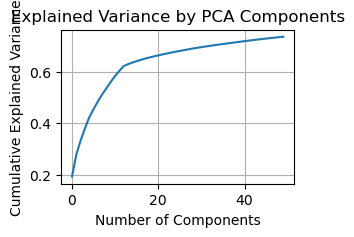

In [24]:
# If you want to visualize the explained variance by components
plt.figure(figsize=(3, 2))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by PCA Components')
plt.grid(True)
plt.savefig('pca_variance.png')
plt.show()

Using first 2 components from PCA reduction for visualization


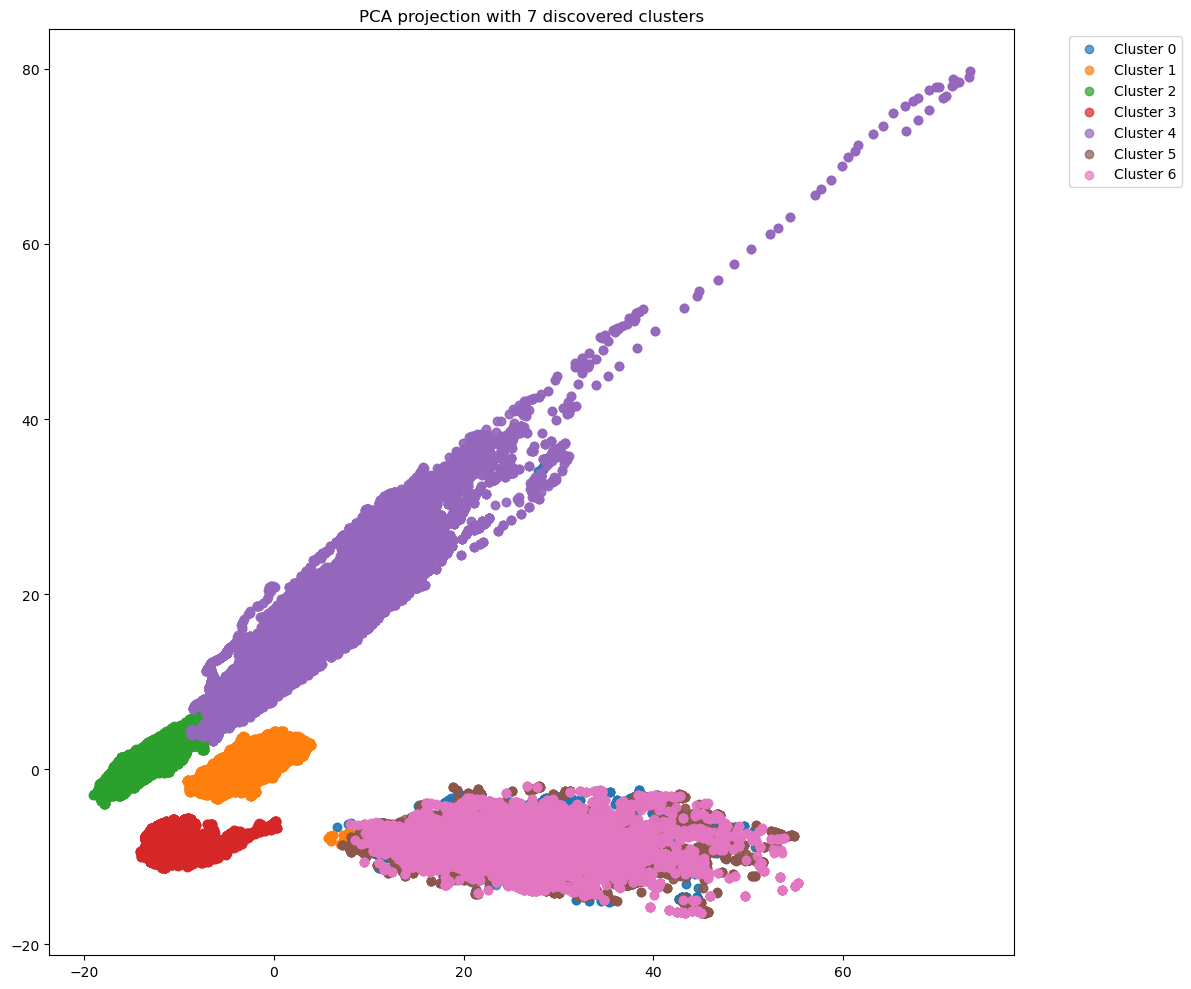

In [34]:
# If you want to visualize the PCA results in 2D
if reduced_features.shape[1] > 2:
    # Extract just the first 2 components for visualization
    embedding = reduced_features[:, :2]
    print(f"Using first 2 components from PCA reduction for visualization")
else:
    # Already 2D
    embedding = reduced_features
    print(f"Using all PCA components for visualization")

# Now plot with cluster assignments
plt.figure(figsize=(12, 10))
for i in range(n_clusters):
    mask = cluster_labels == i
    plt.scatter(embedding[mask, 0], embedding[mask, 1], 
                label=f'Cluster {i}', alpha=0.7)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title(f'PCA projection with {n_clusters} discovered clusters')
plt.tight_layout()
plt.savefig('phoneme_pca_clusters.png', dpi=300)
plt.show()

In [35]:
# Analyze cluster composition
cluster_composition = {}
for i in range(n_clusters):
    mask = cluster_labels == i
    
    # Make sure to use valid_labels (or whatever contains your filtered phoneme labels)
    labels_in_cluster = [valid_labels[j] for j in range(len(valid_labels)) if mask[j]]
    label_counts = Counter(labels_in_cluster)
    cluster_composition[i] = label_counts

print("Cluster composition:")
for cluster, composition in cluster_composition.items():
    print(f"Cluster {cluster}:")
    # Print top 10 most common phonemes in each cluster
    for label, count in composition.most_common(10):
        print(f"  {label}: {count}")

Cluster composition:
Cluster 0:
  ə: 1617
  t: 1175
  r: 999
  n: 907
  l: 721
  k: 718
  d: 656
  s: 567
  v: 554
  ɑ: 536
Cluster 1:
  t: 7829
  ə: 7828
  n: 6018
  r: 5621
  l: 4607
  ɑ: 4011
  k: 4009
  d: 3617
  s: 3014
  ɛ: 2609
Cluster 2:
  ə: 8204
  n: 7199
  t: 6804
  r: 5802
  d: 4001
  l: 3801
  k: 3580
  ɑ: 3401
  s: 2802
  ɛ: 2602
Cluster 3:
  ə: 7805
  t: 6003
  n: 5803
  r: 5601
  l: 3604
  k: 3600
  v: 3203
  d: 3000
  ɑ: 2997
  s: 2203
Cluster 4:
  ə: 7395
  n: 6387
  t: 6004
  r: 5202
  d: 3976
  l: 3800
  k: 3775
  ɑ: 3355
  ɛ: 2403
  s: 2400
Cluster 5:
  ə: 3744
  t: 2772
  r: 2177
  n: 2123
  l: 1696
  k: 1630
  d: 1523
  s: 1364
  v: 1283
  ɑ: 1201
Cluster 6:
  ə: 3429
  t: 2610
  r: 2011
  n: 1957
  l: 1563
  k: 1455
  d: 1415
  s: 1261
  v: 1166
  ɑ: 1064


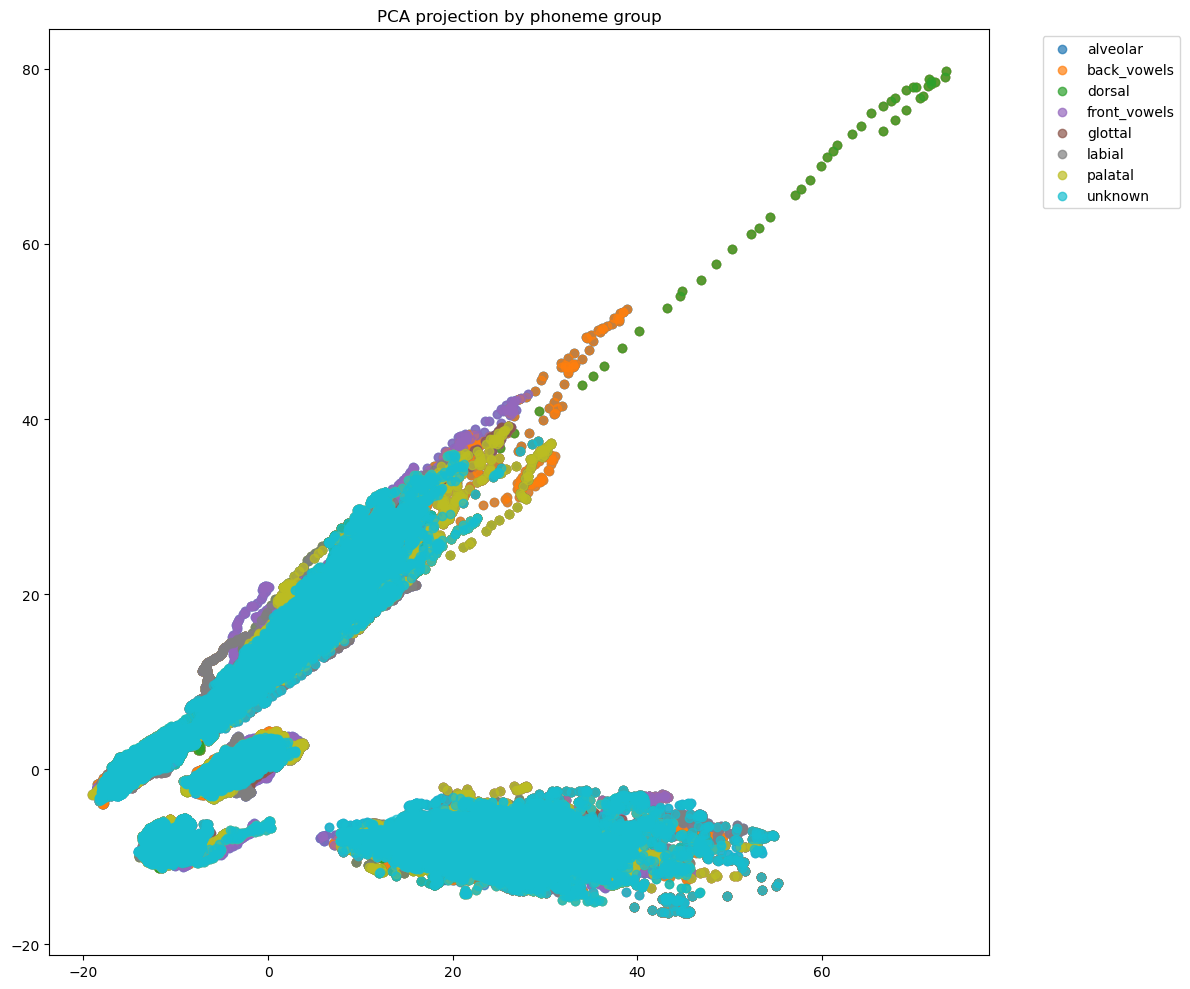

In [33]:
# Create a plot showing phonemes colored by their groups
plt.figure(figsize=(12, 10))
unique_groups = np.unique([g for g in valid_groups if g])
group_colors = plt.cm.tab10(np.linspace(0, 1, len(unique_groups)))

for i, group in enumerate(unique_groups):
    mask = np.array(valid_groups) == group
    plt.scatter(embedding[mask, 0], embedding[mask, 1], 
                color=group_colors[i], label=group, alpha=0.7)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('PCA projection by phoneme group')
plt.tight_layout()
plt.savefig('phoneme_pca_by_group.png', dpi=300)
plt.show()

Cross-tabulation shape: (8, 7)
Index (rows): ['alveolar', 'back_vowels', 'dorsal', 'front_vowels', 'glottal', 'labial', 'palatal', 'unknown']
Columns: ['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4', 'Cluster 5', 'Cluster 6']


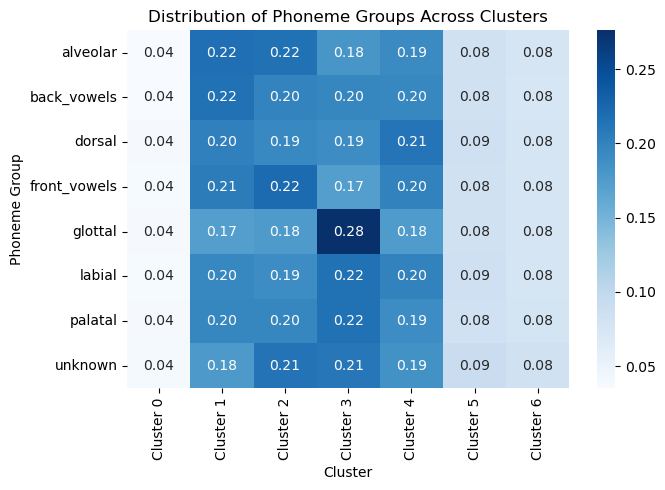


Counts of phonemes in each cluster:
Cluster       Cluster 0  Cluster 1  Cluster 2  Cluster 3  Cluster 4  \
PhonemeGroup                                                          
alveolar           4340      26911      26611      22413      23720   
back_vowels        2648      16022      14809      14602      14548   
dorsal             1288       6813       6580       6402       7177   
front_vowels       1394       7624       8202       6402       7406   
glottal             307       1380       1404       2197       1399   
labial             1498       7811       7605       8604       8001   
palatal            1179       6022       6002       6602       5802   
unknown            1679       7651       9185       9008       7980   

Cluster       Cluster 5  Cluster 6  
PhonemeGroup                        
alveolar          10249       9521  
back_vowels        6144       5597  
dorsal             2899       2614  
front_vowels       3106       2864  
glottal             667       

In [42]:
# Create a DataFrame with the data
df = pd.DataFrame({
    'PhonemeGroup': valid_groups,
    'Cluster': [f"Cluster {i}" for i in cluster_labels]
})

# Create a cross-tabulation (this is similar to a confusion matrix)
# Normalize by phoneme group (row)
cross_tab = pd.crosstab(
    df['PhonemeGroup'], 
    df['Cluster'],
    normalize='index'
)

print("Cross-tabulation shape:", cross_tab.shape)
print("Index (rows):", cross_tab.index.tolist())
print("Columns:", cross_tab.columns.tolist())

# Plot the cross-tabulation as a heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(cross_tab, annot=True, cmap='Blues', fmt='.2f', cbar=True)
plt.xlabel('Cluster')
plt.ylabel('Phoneme Group')
plt.title('Distribution of Phoneme Groups Across Clusters')
plt.tight_layout()
plt.savefig('phoneme_group_distribution.png', dpi=300)
plt.show()

# You can also see the raw counts
cross_tab_counts = pd.crosstab(df['PhonemeGroup'], df['Cluster'])
print("\nCounts of phonemes in each cluster:")
print(cross_tab_counts)

# Calculate metrics using the raw labels
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score

# Convert cluster labels to strings for consistency
cluster_str = [f"Cluster {i}" for i in cluster_labels]

# Calculate metrics
ari = adjusted_rand_score(valid_groups, cluster_str)
ami = adjusted_mutual_info_score(valid_groups, cluster_str)

In [62]:
import plotly.express as px

# Sample a manageable number of points
vis_sample_size = 10000
vis_indices = np.random.choice(len(reduced_features), vis_sample_size, replace=False)

# Predict clusters for this visualization sample
vis_cluster_labels = kmeans.predict(reduced_features[vis_indices])

# Create a DataFrame with the sampled data
df = pd.DataFrame({
    'Component1': features_3d[vis_indices, 0],
    'Component2': features_3d[vis_indices, 1],
    'Component3': features_3d[vis_indices, 2],
    'Cluster': [f'Cluster {c}' for c in vis_cluster_labels]
})

# Create an interactive 3D plot
fig = px.scatter_3d(
    df, 
    x='Component1', 
    y='Component2', 
    z='Component3',
    color='Cluster',
    title='Interactive 3D PCA Projection (10,000 sampled points)',
    opacity=0.7
)

# Add custom camera angles as buttons
camera_angles = {
    'Front View': dict(eye=dict(x=0, y=0, z=2.5)),
    'Top View': dict(eye=dict(x=0, y=2.5, z=0)),
    'Side View': dict(eye=dict(x=2.5, y=0, z=0)),
    'Isometric': dict(eye=dict(x=1.87, y=1.87, z=0.87))
}

# Add camera buttons
fig.update_layout(
    scene_camera=camera_angles['Isometric'],
    updatemenus=[{
        'buttons': [
            {
                'args': ['scene.camera', v],
                'label': k,
                'method': 'relayout'
            } for k, v in camera_angles.items()
        ],
        'type': 'dropdown',
        'showactive': True,
    }]
)

# Save as HTML for interactive viewing
fig.write_html('interactive_clusters_3d.html')

# Display if in a notebook
# fig.show()

C:\Users\irina\anaconda3\Lib\site-packages\plotly\express\_core.py:1979: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  sf: grouped.get_group(s if len(s) > 1 else s[0])


In [46]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn.cluster._kmeans")
warnings.filterwarnings("ignore", category=FutureWarning, module="sklearn.cluster._kmeans")

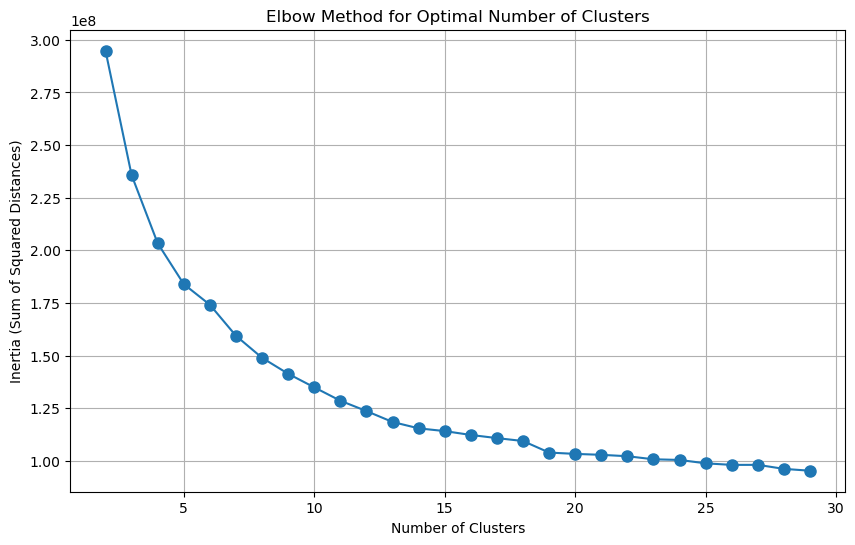

In [55]:
# Calculate inertia (sum of squared distances) for different numbers of clusters
inertia = []
cluster_range = range(2, 30)  # Try 2-14 clusters

for n_clusters in cluster_range:
    kmeans = MiniBatchKMeans(n_clusters=n_clusters, 
                             batch_size=1000, 
                             random_state=42)
    kmeans.fit(reduced_features)
    inertia.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(10, 6))
plt.plot(cluster_range, inertia, 'o-', markersize=8)
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia (Sum of Squared Distances)')
plt.title('Elbow Method for Optimal Number of Clusters')
plt.grid(True)
plt.savefig('elbow_curve.png', dpi=300)
plt.show()

For n_clusters = 2, the silhouette score is 0.078
For n_clusters = 3, the silhouette score is 0.202
For n_clusters = 4, the silhouette score is 0.284
For n_clusters = 5, the silhouette score is 0.334
For n_clusters = 6, the silhouette score is 0.346
For n_clusters = 7, the silhouette score is 0.355
For n_clusters = 8, the silhouette score is 0.267
For n_clusters = 9, the silhouette score is 0.365
For n_clusters = 10, the silhouette score is 0.370
For n_clusters = 11, the silhouette score is 0.369
For n_clusters = 12, the silhouette score is 0.367
For n_clusters = 13, the silhouette score is 0.313
For n_clusters = 14, the silhouette score is 0.271
For n_clusters = 15, the silhouette score is 0.288
For n_clusters = 16, the silhouette score is 0.310
For n_clusters = 17, the silhouette score is 0.303
For n_clusters = 18, the silhouette score is 0.219
For n_clusters = 19, the silhouette score is 0.288
For n_clusters = 20, the silhouette score is 0.231
For n_clusters = 21, the silhouette sco

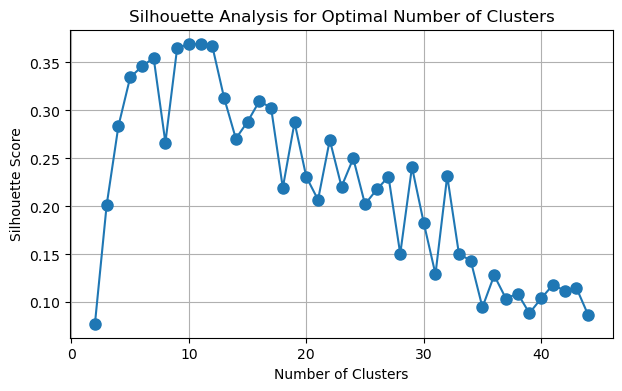

In [75]:
from sklearn.metrics import silhouette_score

# Calculate silhouette scores for different numbers of clusters
# silhouette_scores = []
# cluster_range = range(2, 45)

# # For large datasets, use a sample to speed up computation
# if len(reduced_features) > 10000:
#     sample_indices = np.random.choice(len(reduced_features), 10000, replace=False)
#     sample_features = reduced_features[sample_indices]
# else:
#     sample_features = reduced_features

# for n_clusters in cluster_range:
#     kmeans = MiniBatchKMeans(n_clusters=n_clusters, 
#                              batch_size=1000, 
#                              random_state=42)
#     cluster_labels = kmeans.fit_predict(sample_features)
    
#     # Calculate silhouette score
#     silhouette_avg = silhouette_score(sample_features, cluster_labels)
#     silhouette_scores.append(silhouette_avg)
#     print(f"For n_clusters = {n_clusters}, the silhouette score is {silhouette_avg:.3f}")

# # Plot the silhouette scores
# plt.figure(figsize=(7, 4))
# plt.plot(cluster_range, silhouette_scores, 'o-', markersize=8)
# plt.xlabel('Number of Clusters')
# plt.ylabel('Silhouette Score')
# plt.title('Silhouette Analysis for Optimal Number of Clusters')
# plt.grid(True)
plt.savefig('silhouette_analysis.png', dpi=300)
plt.show()

In [69]:
# Function to calculate gap statistic (simplified)
def compute_gap(data, k_max=35, n_references=5):  # Increased k_max to 30
    """
    Compute gap statistic for determining optimal k
    """
    # Standardize data
    scaler = StandardScaler()
    data = scaler.fit_transform(data)
    
    # Sample size
    n = data.shape[0]
    
    # Create references (random uniform data)
    shape = data.shape
    references = []
    for i in range(n_references):
        # Create a random uniform distribution over the data range
        reference = np.random.random(size=shape)
        # Scale the reference to the range of the original data
        reference = reference * (data.max(axis=0) - data.min(axis=0)) + data.min(axis=0)
        references.append(reference)
    
    # Compute gaps for each k
    gaps = []
    std_gaps = []  # Also store standard deviations for computing error bars
    
    # Add progress tracking
    print(f"Computing gap statistic for k = 1 to {k_max}...")
    
    for k in range(1, k_max + 1):
        print(f"Processing k = {k}/{k_max}...", end="\r")
        
        # Fit KMeans to the real data
        kmeans = KMeans(n_clusters=k, random_state=42)
        kmeans.fit(data)
        disp_real = kmeans.inertia_
        
        # Fit KMeans to each reference dataset
        disp_refs = []
        for reference in references:
            kmeans = KMeans(n_clusters=k, random_state=42)
            kmeans.fit(reference)
            disp_refs.append(kmeans.inertia_)
        
        # Calculate gap and standard deviation
        gap = np.log(np.mean(disp_refs)) - np.log(disp_real)
        sd_gap = np.std(np.log(disp_refs)) * np.sqrt(1 + 1/n_references)
        
        gaps.append(gap)
        std_gaps.append(sd_gap)
    
    return gaps, std_gaps

Computing gap statistic for k = 1 to 45...


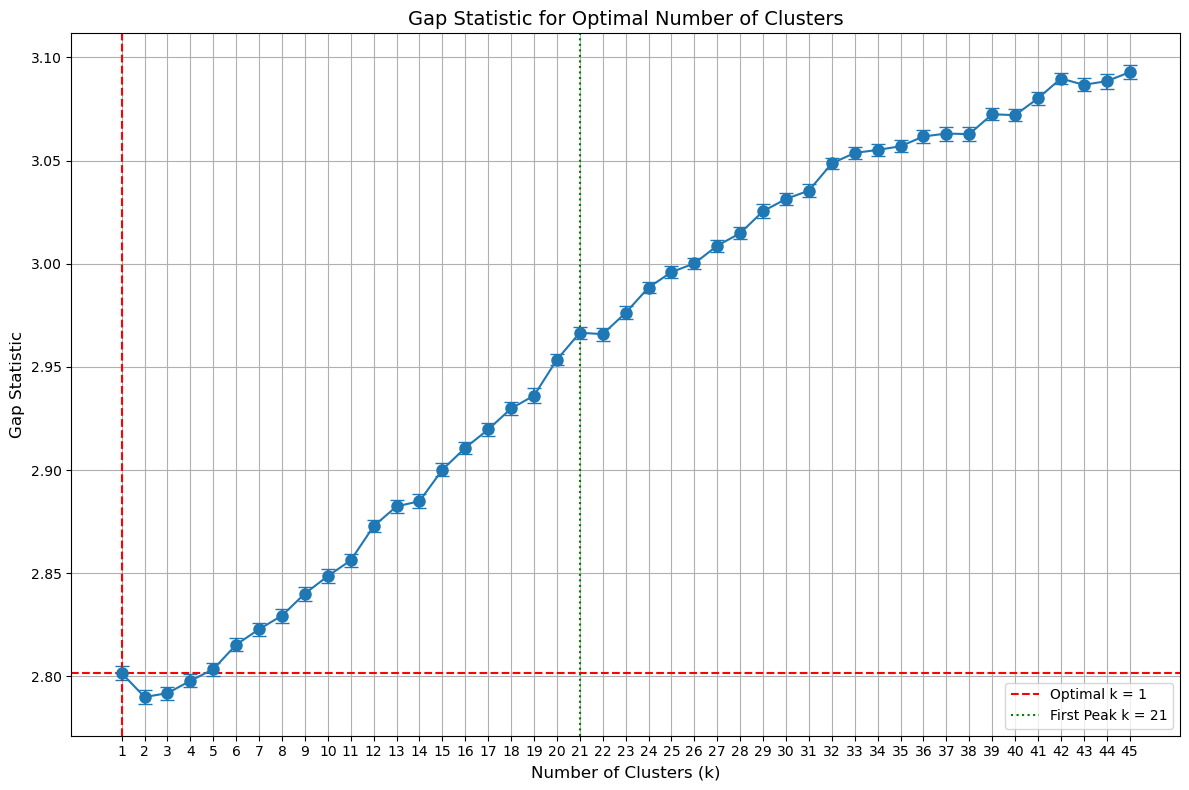


Gap statistic values:
k = 1: 2.802 ± 0.003
k = 2: 2.790 ± 0.003
k = 3: 2.792 ± 0.003
k = 4: 2.798 ± 0.003
k = 5: 2.803 ± 0.003
k = 6: 2.815 ± 0.003
k = 7: 2.823 ± 0.003
k = 8: 2.829 ± 0.003
k = 9: 2.840 ± 0.003
k = 10: 2.849 ± 0.003
k = 11: 2.856 ± 0.003
k = 12: 2.873 ± 0.003
k = 13: 2.882 ± 0.003
k = 14: 2.885 ± 0.003
k = 15: 2.900 ± 0.003
k = 16: 2.911 ± 0.003
k = 17: 2.920 ± 0.003
k = 18: 2.930 ± 0.003
k = 19: 2.936 ± 0.004
k = 20: 2.954 ± 0.003
k = 21: 2.967 ± 0.003
k = 22: 2.966 ± 0.003
k = 23: 2.976 ± 0.003
k = 24: 2.988 ± 0.003
k = 25: 2.996 ± 0.003
k = 26: 3.000 ± 0.003
k = 27: 3.009 ± 0.003
k = 28: 3.015 ± 0.003
k = 29: 3.025 ± 0.003
k = 30: 3.031 ± 0.003
k = 31: 3.035 ± 0.003
k = 32: 3.049 ± 0.003
k = 33: 3.054 ± 0.003
k = 34: 3.055 ± 0.003
k = 35: 3.057 ± 0.003
k = 36: 3.062 ± 0.003
k = 37: 3.063 ± 0.003
k = 38: 3.063 ± 0.004
k = 39: 3.072 ± 0.003
k = 40: 3.072 ± 0.003
k = 41: 3.080 ± 0.003
k = 42: 3.090 ± 0.003
k = 43: 3.087 ± 0.003
k = 44: 3.089 ± 0.004
k = 45: 3.093 ± 0.

In [72]:
# # For large datasets, use a sample
# if len(reduced_features) > 5000:
#     sample_indices = np.random.choice(len(reduced_features), 5000, replace=False)
#     sample_features = reduced_features[sample_indices]
# else:
#     sample_features = reduced_features

# # Compute gap statistic with increased k_max
# gaps, std_gaps = compute_gap(sample_features, k_max=45)  

# # Plot the gap statistic with error bars
# plt.figure(figsize=(12, 8))
# k_values = range(1, len(gaps) + 1)
# plt.errorbar(k_values, gaps, yerr=std_gaps, fmt='o-', markersize=8, capsize=5)
# plt.xlabel('Number of Clusters (k)', fontsize=12)
# plt.ylabel('Gap Statistic', fontsize=12)
# plt.title('Gap Statistic for Optimal Number of Clusters', fontsize=14)
# plt.grid(True)
# plt.xticks(k_values)  # Show all k values on x-axis

# # Add horizontal and vertical lines to help identify the optimal k
# # This finds the first k where gap[k] ≥ gap[k+1] - std_gaps[k+1]
# optimal_k = 1
# for k in range(1, len(gaps)):
#     if gaps[k-1] >= gaps[k] - std_gaps[k]:
#         optimal_k = k
#         break

# if optimal_k < len(gaps):
#     plt.axvline(x=optimal_k, color='r', linestyle='--', label=f'Optimal k = {optimal_k}')
#     plt.axhline(y=gaps[optimal_k-1], color='r', linestyle='--')

# # Add a more sophisticated method that finds the first significant peak
# # using the gap statistic criterion
# optimal_k2 = None
# for k in range(1, len(gaps)-1):
#     if gaps[k] > gaps[k-1] and gaps[k] >= gaps[k+1]:
#         # Found a peak
#         if k+1 < len(gaps) and gaps[k] >= gaps[k+1] - std_gaps[k+1]:
#             optimal_k2 = k+1  # Gap statistic criterion suggests this k
#             break

# if optimal_k2:
#     plt.axvline(x=optimal_k2, color='g', linestyle=':', label=f'First Peak k = {optimal_k2}')

# plt.legend()
# plt.tight_layout()
plt.savefig('gap_statistic_extended.png', dpi=300)
plt.show()

# Print the raw gap values for reference
print("\nGap statistic values:")
for k, gap in enumerate(gaps, 1):
    print(f"k = {k}: {gap:.3f} ± {std_gaps[k-1]:.3f}")


In [101]:
from sklearn.cluster import MiniBatchKMeans
from collections import defaultdict
from collections import Counter

n_clusters = 15

# Perform clustering
kmeans = MiniBatchKMeans(n_clusters=n_clusters, batch_size=3072, n_init=3, random_state=42)
cluster_labels = kmeans.fit_predict(scaled_features)

# 4. Map phonemes to clusters
phoneme_to_cluster = defaultdict(list)
for phoneme, cluster in zip(all_phoneme_labels, cluster_labels):
    phoneme_to_cluster[phoneme].append(cluster)
    
# 5. Assign each phoneme to its most common cluster
phoneme_cluster_mapping = {}
for phoneme, clusters in phoneme_to_cluster.items():
    
    most_common_cluster = Counter(clusters).most_common(1)[0][0]
    phoneme_cluster_mapping[phoneme] = f"cluster_{most_common_cluster}"
    
# 6. Create cluster groups
cluster_groups = defaultdict(list)
for phoneme, cluster in phoneme_cluster_mapping.items():
    cluster_groups[cluster].append(phoneme)
    
cluster_groups

defaultdict(list,
            {'cluster_2': ['h', 'ɔ', 'v', 'u', 'e', 'øː', 'ʃ'],
             'cluster_4': ['ɛ',
              'f',
              't',
              'p',
              's',
              'iː',
              'ə',
              'n',
              'x',
              'ʋ',
              'ʋɑ',
              'ɪx',
              'y',
              'ɪ',
              'aː',
              'ʏ',
              'ɔf',
              'ŋ',
              'ɑu',
              'ɔx',
              'tʋ',
              'ŋk',
              'sx',
              'ʋɪ',
              'o',
              'ts'],
             'cluster_0': ['l',
              'i',
              'r',
              'k',
              'm',
              'z',
              'eː',
              'd',
              'œy',
              'b',
              'a',
              'oː',
              'ɑ',
              'ɣ',
              'ɛi',
              'uː',
              'j']})